<h3> Ejercicio 2: Maximizar la cantidad de unos en un individuo binario
</h3>

In [9]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [10]:
def fitness(individuo):
    return sum(individuo)

In [11]:
def crear_poblacion(tamano_poblacion, longitud_individuo):
    return [[random.randint(0, 1) for _ in range(longitud_individuo)]
            for _ in range(tamano_poblacion)]


In [12]:
def seleccion_torneo(poblacion, k=3):
    participantes = random.sample(poblacion, k)
    return max(participantes, key=fitness)

In [13]:
def cruzamiento(padre1, padre2):
    punto = random.randint(1, len(padre1) - 1)
    hijo1 = padre1[:punto] + padre2[punto:]
    hijo2 = padre2[:punto] + padre1[punto:]
    return hijo1, hijo2

In [14]:
def mutacion(individuo, tasa=0.05):
    return [bit if random.random() > tasa else 1 - bit for bit in individuo]


In [15]:
def algoritmo_genetico_max_unos(generaciones=20, tamano_poblacion=6, longitud_individuo=10):
    poblacion = crear_poblacion(tamano_poblacion, longitud_individuo)
    historial_max = []

    print("Población inicial:", poblacion)

    for _ in range(generaciones):
        nueva_poblacion = []

        # Se generan parejas de padres y se crean hijos
        for _ in range(tamano_poblacion // 2):
            padre1 = seleccion_torneo(poblacion)
            padre2 = seleccion_torneo(poblacion)
            hijo1, hijo2 = cruzamiento(padre1, padre2)
            hijo1 = mutacion(hijo1)
            hijo2 = mutacion(hijo2)
            nueva_poblacion.extend([hijo1, hijo2])

        poblacion = nueva_poblacion
        mejor = max(poblacion, key=fitness)
        historial_max.append(fitness(mejor))

    # Gráfica de la evolución del mejor fitness (cantidad de unos)
    plt.plot(historial_max)
    plt.title("Mejor fitness por generación")
    plt.xlabel("Generación")
    plt.ylabel("Cantidad de unos")
    plt.grid(True)
    plt.show()

    return max(poblacion, key=fitness)

Población inicial: [[1, 0, 1, 1, 0, 0, 0, 0, 1, 0], [1, 1, 1, 1, 1, 1, 0, 1, 1, 1], [1, 0, 1, 0, 1, 1, 1, 1, 0, 1], [1, 0, 1, 1, 0, 0, 1, 1, 0, 1], [1, 0, 0, 0, 0, 1, 1, 0, 1, 1], [1, 0, 1, 0, 1, 0, 1, 1, 0, 0]]


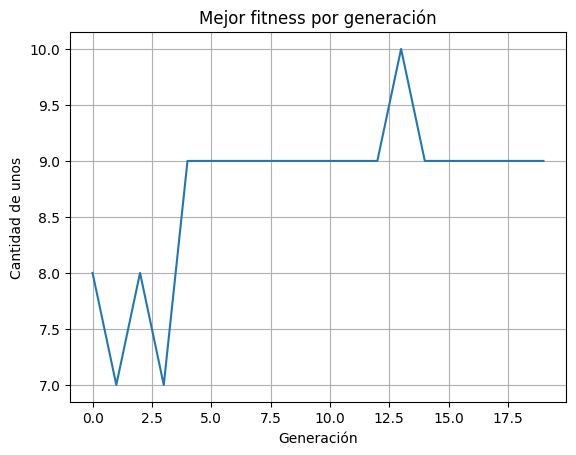

Mejor solución encontrada: [1, 1, 1, 1, 1, 1, 1, 0, 1, 1] Cantidad de unos: 9


In [16]:
mejor_solucion = algoritmo_genetico_max_unos()
print("Mejor solución encontrada:", mejor_solucion,
      "Cantidad de unos:", fitness(mejor_solucion))